# AT5
### **Instruções**

Crie um notebook AT5.ipynb no seu repositório de atividades.

O seu notebook deverá implementar os seguintes passo:

Carregar o arquivo train.csv disponível em:https://www.kaggle.com/c/titanic/data;

Indicar a quantidade de linhas e colunas do dataset;

Indicar o tipo de dado de cada variável;

Realizar um resumo estatístico das variáveis;

Criar uma tabela de frequência e um gráfico pra a variável "survival". Explique a escolha do tipo de gráfico;

Quantas pessoas sobreviveram? Qual a classe mais frequente?

Avalie a relação entre a variável "sex" e a variável "survival". Crie uma tabela de frequência e um gráfico. Mulheres sovreviveram mais que homes?

Qual é  distribuição das idades dos passageiros? Crie um gráfico para visualizar a distribuição. Parece simétrica? A maioria dos passageiros era jovem ou idosa?

## Imports e busca no banco

In [1]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("train.csv")

## Indicar a quantidade de linhas e colunas do dataset

In [2]:
df = pd.read_csv("train.csv")

quant_linhas = len(df.index)
quant_colunas = len(df.columns)


print("Quantidade de linhas: ", quant_linhas)
print("Quantidade de colunas: ", quant_colunas)


Quantidade de linhas:  891
Quantidade de colunas:  12


## Indicar o tipo de dado de cada variável

In [3]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

## Realizar um resumo estatístico das variáveis

In [4]:
resumo = df.describe()
print(resumo)

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


## Criar uma tabela de frequência e um gráfico pra a variável "survival". Explique a escolha do tipo de 

**Por que?**

Foi escolhido o gráfico de pizza, pois a variável 'Survived' ser simples (True ou False) faz com que a visualização nesse estilo se torne fácil e intuitiva.

,Survived,%
0,0,61.62
1,1,38.38


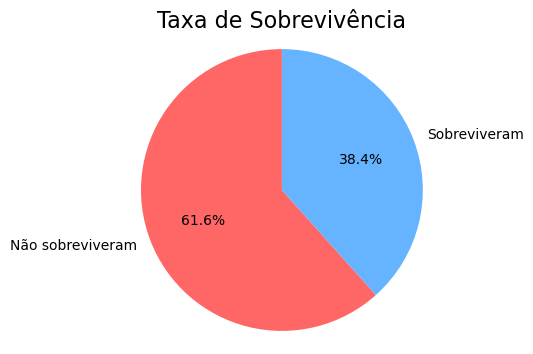

In [5]:
quant_total = len(df.index)
sobreviveram = len(df[df['Survived'] == 1])
nao_sobreviveram = len(df[df['Survived'] == 0])

f_sobreviveram = (sobreviveram / quant_total) * 100
f_nao_sobreviveram = (nao_sobreviveram / quant_total) * 100

f_sobreviveram = f"{f_sobreviveram:.2f}"
f_nao_sobreviveram = f"{f_nao_sobreviveram:.2f}"

df_result_sobrev = pd.DataFrame({
    'Survived': [0, 1],
    '%': [f_nao_sobreviveram, f_sobreviveram],
})


labels = ['Não sobreviveram', 'Sobreviveram']
sizes = [f_nao_sobreviveram, f_sobreviveram]
colors = ['#ff6666', '#66b3ff']
plt.figure(figsize=(4, 4))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Taxa de Sobrevivência', fontsize=16)
plt.axis('equal')



display(df_result_sobrev)
plt.show()

## Quantas pessoas sobreviveram? Qual a classe mais frequente?

In [6]:
sobreviveram = len(df[df['Survived'] == 1])
class_predominante = df['Pclass'].mode()[0]

print("Sobreviveram: ", sobreviveram)
print(f"Classe mais frequente: {class_predominante}º")


Sobreviveram:  342
Classe mais frequente: 3º


## Avalie a relação entre a variável "sex" e a variável "survival". Crie uma tabela de frequência e um gráfico. Mulheres sovreviveram mais que homes?

Survived    0    1
Sex               
female     81  233
male      468  109


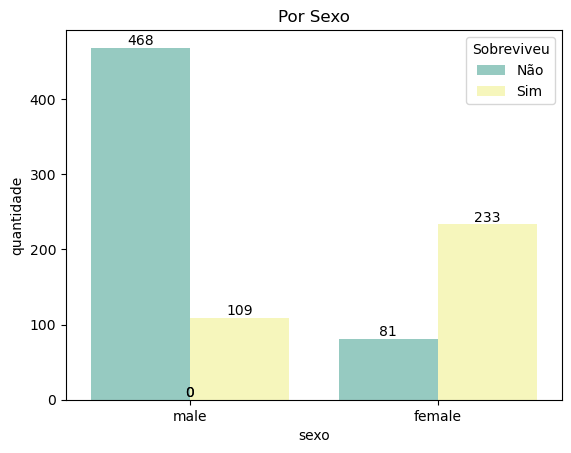

In [7]:
sex_survived = pd.crosstab(df['Sex'], df['Survived'])

print(sex_survived)


pd_result_sex_suvival = sns.countplot(
    x='Sex',
    hue='Survived',
    data=df,
    palette='Set3'
)

plt.title('Por Sexo')
plt.xlabel('sexo')
plt.ylabel('quantidade')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])

for barra in pd_result_sex_suvival.patches:
    altura = barra.get_height()

    pd_result_sex_suvival.annotate(
        f'{int(altura)}',
        (barra.get_x() + barra.get_width() / 2, altura),
        ha='center',
        va='bottom'
    )

plt.show()

## Qual é distribuição das idades dos passageiros? Crie um gráfico para visualizar a distribuição. Parece simétrica? A maioria dos passageiros era jovem ou idosa?

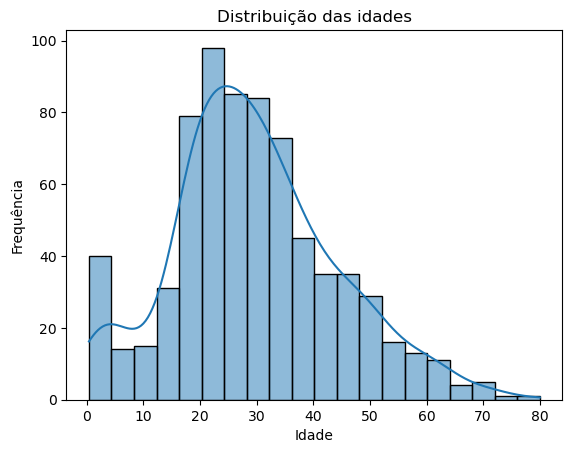

In [8]:
sns.histplot(df['Age'].dropna(), bins=20, kde=True)
plt.title('Distribuição das idades')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()